In [2]:
!git clone https://github.com/eliftufekci/k_shortest_path_with_diversity.git

fatal: destination path 'k_shortest_path_with_diversity' already exists and is not an empty directory.


In [3]:
import sys

top_level_container_dir = "k_shortest_path_with_diversity/"

if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

In [4]:
import gc
import networkx as nx
import random
import datetime
import numpy as np

from k_shortest_path_with_diversity.examples import draw_bar_chart, download_and_prepare_graphs
from k_shortest_path_with_diversity.examples.draw_distribution import draw_time_distribution, draw_num_of_path_distribution
from k_shortest_path_with_diversity.src.algorithms import FindKSPD, FindKSPD_Yen, FindKSPD_Minus

In [5]:
def run_algorithm(algorithm, G, threshold, k, node_pairs):
    times = []
    num_paths = []

    for src, dest in node_pairs:
        print(f"\nComparing algorithms for SRC: {src}, DEST: {dest}")

        start_time = datetime.datetime.now()
        alg = algorithm(G, threshold)
        result = alg.find_paths(src=src, dest=dest, k=k)
        end_time = datetime.datetime.now()
        execution_time = end_time - start_time

        times.append(execution_time.total_seconds())
        num_paths.append(alg.number_of_paths_explored)


    return times, num_paths

In [6]:
def upload_graph(filepath, num_pairs):
    G = nx.DiGraph()
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:  # Weighted graph (3 parçalı satır: kaynak, hedef, ağırlık)
                u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
                G.add_edge(u, v, weight=weight)
            elif len(parts) == 2:  # Unweighted graph (2 parçalı satır: kaynak ve hedef)
                u, v = map(int, parts)
                G.add_edge(u, v, weight=1)  # Ağırlıksız kenarları varsayılan olarak '1' ağırlıkla ekle
            else:
                raise ValueError("Unexpected line format in graph file.")

    node_pairs = []
    for _ in range(num_pairs):
        src = random.choice(list(G.nodes()))
        reachable = list(nx.descendants(G, src))

        while not reachable:
            src = random.choice(list(G.nodes()))
            reachable = list(nx.descendants(G, src))

        dest = random.choice(reachable)
        node_pairs.append((src, dest))

    return G, node_pairs

In [7]:
download_and_prepare_graphs()

k_to_find = 10
diversity_threshold = 0.6

Downloading: https://snap.stanford.edu/data/web-Google.txt.gz
Extracting: /content/graph-data/web-Google.txt.gz -> /content/graph-data/web-Google.txt
Removed archive: /content/graph-data/web-Google.txt.gz
Done: /content/graph-data/web-Google.txt
Downloading: https://snap.stanford.edu/data/wiki-Talk.txt.gz
Extracting: /content/graph-data/wiki-Talk.txt.gz -> /content/graph-data/wiki-Talk.txt
Removed archive: /content/graph-data/wiki-Talk.txt.gz
Done: /content/graph-data/wiki-Talk.txt
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.FLA.gr.gz
Extracting: /content/graph-data/USA-road-d.FLA.gr.gz -> /content/graph-data/USA-road-d.FLA.gr
Removed archive: /content/graph-data/USA-road-d.FLA.gr.gz
Done: /content/graph-data/USA-road-d.FLA.gr
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.COL.gr.gz
Extracting: /content/graph-data/USA-road-d.COL.gr.gz -> /content/graph-data/USA-road-d.COL.gr
Removed archive: /content/graph-data/USA-ro

In [8]:
web_google_path = "/content/graph-data/web-Google.txt"
num_pairs = 50
G, node_pairs = upload_graph(web_google_path, num_pairs)

print(node_pairs)

[(591230, 345461), (197290, 732876), (750882, 884440), (209718, 113780), (74414, 20863), (906170, 89895), (767904, 595868), (911264, 653119), (548683, 461158), (846530, 311413), (553510, 188021), (196111, 561941), (53324, 261), (147216, 214858), (192250, 514806), (75927, 868144), (106430, 430129), (695938, 643666), (480544, 784989), (190396, 82005), (246127, 866020), (361674, 768322), (679188, 126195), (338456, 830424), (275572, 375468), (181847, 304534), (115492, 519749), (703754, 748044), (348974, 474825), (880532, 246008), (39709, 613604), (704392, 872649), (747459, 460261), (196667, 242991), (251676, 899756), (91071, 148057), (204750, 846850), (80775, 470263), (60388, 67819), (637062, 784787), (464067, 151703), (872905, 136922), (671307, 297233), (122848, 127753), (29807, 188980), (243338, 533526), (662262, 571044), (260129, 515833), (300991, 748252), (381827, 761906)]


In [9]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 591230, DEST: 345461

Comparing algorithms for SRC: 197290, DEST: 732876

Comparing algorithms for SRC: 750882, DEST: 884440

Comparing algorithms for SRC: 209718, DEST: 113780

Comparing algorithms for SRC: 74414, DEST: 20863

Comparing algorithms for SRC: 906170, DEST: 89895

Comparing algorithms for SRC: 767904, DEST: 595868

Comparing algorithms for SRC: 911264, DEST: 653119

Comparing algorithms for SRC: 548683, DEST: 461158

Comparing algorithms for SRC: 846530, DEST: 311413

Comparing algorithms for SRC: 553510, DEST: 188021

Comparing algorithms for SRC: 196111, DEST: 561941

Comparing algorithms for SRC: 53324, DEST: 261

Comparing algorithms for SRC: 147216, DEST: 214858

Comparing algorithms for SRC: 192250, DEST: 514806

Comparing algorithms for SRC: 75927, DEST: 868144

Comparing algorithms for SRC: 106430, DEST: 430129

Comparing algorithms for SRC: 695938, DEST: 643666

Comparing algorithms for SRC: 480544, DEST: 784989

C

In [10]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 591230, DEST: 345461

Comparing algorithms for SRC: 197290, DEST: 732876

Comparing algorithms for SRC: 750882, DEST: 884440

Comparing algorithms for SRC: 209718, DEST: 113780

Comparing algorithms for SRC: 74414, DEST: 20863

Comparing algorithms for SRC: 906170, DEST: 89895

Comparing algorithms for SRC: 767904, DEST: 595868

Comparing algorithms for SRC: 911264, DEST: 653119

Comparing algorithms for SRC: 548683, DEST: 461158

Comparing algorithms for SRC: 846530, DEST: 311413

Comparing algorithms for SRC: 553510, DEST: 188021

Comparing algorithms for SRC: 196111, DEST: 561941

Comparing algorithms for SRC: 53324, DEST: 261

Comparing algorithms for SRC: 147216, DEST: 214858

Comparing algorithms for SRC: 192250, DEST: 514806

Comparing algorithms for SRC: 75927, DEST: 868144

Comparing algorithms for SRC: 106430, DEST: 430129

Comparing algorithms for SRC: 695938, DEST: 643666

Comparing algorithms for SRC: 480544, DEST: 784

In [11]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [12]:
web_google_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(web_google_result)

((np.float64(33.80602562), np.float64(102.94), [38.27031, 31.848766, 43.04204, 36.185116, 40.8018, 22.586582, 49.404681, 23.651227, 25.749549, 30.751324, 40.314198, 14.135857, 16.310595, 41.880111, 33.278707, 25.322987, 35.24834, 37.203676, 27.247212, 33.551702, 42.328935, 29.537775, 42.94143, 29.821793, 40.890255, 23.092307, 35.903322, 44.837056, 31.010624, 25.534183, 41.998205, 14.871176, 27.567122, 39.828532, 14.449758, 51.457984, 31.874304, 19.888274, 42.424286, 23.61911, 58.626632, 41.029796, 58.960803, 34.356953, 23.593159, 31.356939, 26.31606, 35.737736, 45.801423, 33.860569], [217, 192, 86, 73, 170, 9, 313, 1, 74, 69, 63, 1, 1, 33, 48, 33, 64, 76, 29, 89, 29, 21, 23, 92, 329, 81, 58, 92, 94, 37, 55, 1, 98, 98, 0, 251, 9, 9, 80, 79, 382, 47, 634, 143, 8, 90, 123, 69, 382, 92]), (np.float64(42.414587000000004), np.float64(170.84), [42.953419, 28.752677, 38.037982, 38.284835, 296.406845, 23.376331, 185.595699, 23.913728, 27.765227, 28.336871, 42.169397, 15.327361, 14.62427, 41.442

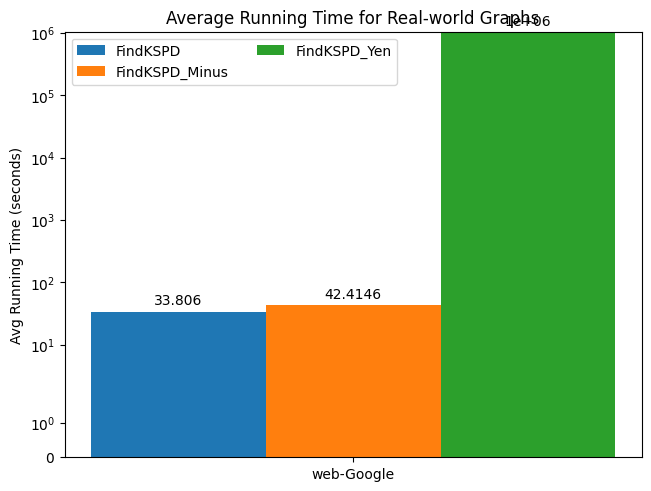

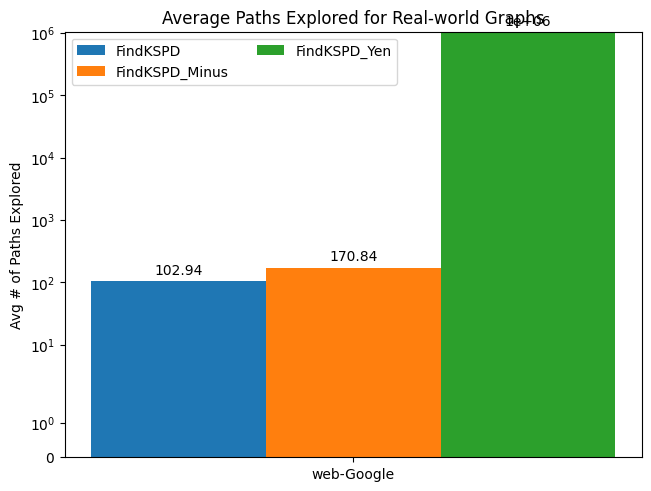

In [13]:
graph_types = ("web-Google",)

algorithms_time = {
    'FindKSPD':       [web_google_result[0][0]],  # index 0 = avg_time
    'FindKSPD_Minus': [web_google_result[1][0]],
    'FindKSPD_Yen':   [web_google_result[2][0]],
}

algorithms_paths = {
    'FindKSPD':       [web_google_result[0][1]],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [web_google_result[1][1]],
    'FindKSPD_Yen':   [web_google_result[2][1]],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [14]:
del G
gc.collect()

1465119

In [15]:
wiki_talk_path  = "/content/graph-data/wiki-Talk.txt"
num_pairs = 50
G, node_pairs = upload_graph(wiki_talk_path, num_pairs)
print(node_pairs)

[(1097683, 86067), (669559, 865600), (705316, 662584), (324635, 1670237), (1022511, 2136983), (29708, 1028772), (844540, 685886), (1479118, 2092000), (26419, 517379), (10126, 2131555), (941161, 1543087), (355991, 355992), (1714646, 2211226), (164738, 778382), (1473759, 1473760), (720947, 1101435), (34030, 1200848), (803603, 86482), (38144, 1246382), (34369, 1039200), (449034, 1796485), (274620, 125880), (8534, 1759956), (45648, 7993), (262683, 361345), (118864, 2132405), (745023, 745024), (1130146, 1271398), (237124, 753773), (68689, 1273959), (188292, 232407), (53361, 2380098), (83634, 1508256), (1342417, 1801208), (478246, 1407796), (739368, 2243766), (72418, 1027720), (49701, 1885897), (10135, 828178), (166043, 104764), (683281, 2151883), (79134, 2220161), (745793, 1567831), (485469, 2188470), (1151567, 1151568), (40165, 960284), (904849, 1881398), (1008197, 380501), (94631, 424112), (466002, 678138)]


In [16]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

working with KSPD

Comparing algorithms for SRC: 1097683, DEST: 86067

Comparing algorithms for SRC: 669559, DEST: 865600

Comparing algorithms for SRC: 705316, DEST: 662584

Comparing algorithms for SRC: 324635, DEST: 1670237

Comparing algorithms for SRC: 1022511, DEST: 2136983

Comparing algorithms for SRC: 29708, DEST: 1028772

Comparing algorithms for SRC: 844540, DEST: 685886

Comparing algorithms for SRC: 1479118, DEST: 2092000

Comparing algorithms for SRC: 26419, DEST: 517379

Comparing algorithms for SRC: 10126, DEST: 2131555

Comparing algorithms for SRC: 941161, DEST: 1543087

Comparing algorithms for SRC: 355991, DEST: 355992

Comparing algorithms for SRC: 1714646, DEST: 2211226

Comparing algorithms for SRC: 164738, DEST: 778382

Comparing algorithms for SRC: 1473759, DEST: 1473760

Comparing algorithms for SRC: 720947, DEST: 1101435

Comparing algorithms for SRC: 34030, DEST: 1200848

Comparing algorithms for SRC: 803603, DEST: 86482

Comparing algorithms for SRC: 38144,

In [17]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

working with KSPD_Minus

Comparing algorithms for SRC: 1097683, DEST: 86067

Comparing algorithms for SRC: 669559, DEST: 865600


KeyboardInterrupt: 

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
wiki_talk_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(wiki_talk_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result]

graph_types = ("web-Google", "wiki-Talk")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
roadCOL_path    = "/content/graph-data/USA-road-d.COL.gr"
num_pairs = 5
G, node_pairs = upload_graph(roadCOL_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadCOL_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(roadCOL_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadCOL_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}
draw_bar_chart(graph_types, algorithms_paths, algorithms_time)

In [ ]:
del G
gc.collect()

In [ ]:
roadFLA_path = "/content/graph-data/USA-road-d.FLA.gr"
num_pairs = 5
G, node_pairs = upload_graph(roadFLA_path, num_pairs)
print(node_pairs)

In [ ]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

kspd_avg_time = np.average(kspd_times) if kspd_times else 0
kspd_avg_num_paths = np.average(kspd_num_paths) if kspd_num_paths else 0

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")
print(f"kspd_avg_time: {kspd_avg_time}")
print(f"kspd_avg_num_paths: {kspd_avg_num_paths}")

In [ ]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

kspd_minus_avg_time = np.average(kspd_minus_times) if kspd_minus_times else 0
kspd_minus_avg_num_paths = np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")
print(f"kspd_minus_avg_time: {kspd_minus_avg_time}")
print(f"kspd_minus_avg_num_paths: {kspd_minus_avg_num_paths}")

In [ ]:
# print("working with KSPD_Yen")
# kspd_yen_times, kspd_yen_num_paths = run_algorithm(FindKSPD_Yen, G, diversity_threshold, k_to_find, node_pairs)

# kspd_yen_avg_time = np.average(kspd_yen_times) if kspd_yen_times else 0
# kspd_yen_avg_num_paths = np.average(kspd_yen_num_paths) if kspd_yen_num_paths else 0

kspd_yen_times = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted
kspd_yen_num_paths = np.full((num_pairs,), float('inf')) # Keep as inf for distribution plots if not intended to be plotted

kspd_yen_avg_time = 10**6
kspd_yen_avg_num_paths =  10**6

In [ ]:
roadFLA_result = ((kspd_avg_time, kspd_avg_num_paths, kspd_times, kspd_num_paths),
                     (kspd_minus_avg_time, kspd_minus_avg_num_paths, kspd_minus_times, kspd_minus_num_paths),
                     (kspd_yen_avg_time, kspd_yen_avg_num_paths, kspd_yen_times, kspd_yen_num_paths))

print(roadFLA_result)

In [ ]:
all_results = [web_google_result, wiki_talk_result, roadCOL_result, roadFLA_result]

graph_types = ("web-Google", "wiki-Talk", "RoadCOL", "RoadFLA")

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
    'FindKSPD_Yen':   [r[2][0] for r in all_results],
}

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
    'FindKSPD_Yen':   [r[2][1] for r in all_results],
}

draw_bar_chart(graph_types, algorithms_paths, algorithms_time)